# 02 — Environmental Parameters

`POST /v1/env_params` returns thermal-comfort, air-quality, and solar-irradiance metrics for a point.

**Plan:** available on both tiers.

We'll request a range of hours at a point, then plot the time-series parameters returned.

### About the `temperature` input

When you call `client.environmental_parameters(...)` for a `(latitude, longitude)`, the payload **requires** a `temperature` value — the ambient air temperature at that point, in °C. The API uses it as the thermal anchor when it derives the downstream values (heat index, apparent temperature, wet-bulb, etc.), so the response is consistent with the actual conditions on the ground rather than a generic climatology.

In a real workflow you'd source this from the heatmap (see the use-case notebooks under `notebooks/use_cases/` — they pass each location's peak temperature from `client.create_heatmap` straight into `temperature=`). In this demo we hard-code `temperature=8.47` as the known ambient at the chosen lat/lon on `2022-06-02 00:00` — that's why that specific number appears below.


### Reference: filter types

Same `date_time` filter types as the heatmap endpoint (which also supports `filter_type=4`, range of days) — the payload changes shape per filter:

| `filter_type` | Meaning | Required keyword args | Response shape |
|---|---|---|---|
| `1` | **Single hour** | `start_date`, `start_time` | Each parameter is a single value |
| `2` | **Range of hours** (same day) | `start_date`, `start_time`, `end_time` | Each parameter is an array sized to the hour range (e.g. 16 values for `00:00`→`15:00`) |
| `3` | **Single day** | `start_date` | Each parameter is a length-24 array covering the full day 00:00–23:59 (`start_time` is ignored) |
| `4` | **Range of days** (window ≤ ~31 days) | `start_date`, `end_date` | Each parameter is arrayed across the multi-day window |

The cell below uses `filter_type=2`. The use-case notebooks use `filter_type=3` for the full diurnal heat-index / wet-bulb / humidity curves at each top-N hotspot.

### Reference: response schema

`client.environmental_parameters(...)` returns `{"activity_id": str, "result": dict}`. The `result` carries:

- **`metadata`**
  - `time_range`: `{start, end, interval, count}` — ISO timestamps and the number of hourly samples in the response.
  - `timestamps`: list of ISO timestamps, one per sample.
  - `timezone`, `timezone_offset_hours`.
- **`locations`** — list of point results. Each location has:
  - `lat`, `lon`, `elevation` (meters).
  - `temperature` — the anchor you passed in, echoed back.
  - `parameters` — the time-series dict (see below).
  - `solar_irradiance.clear_sky` — `{ghi, dni, dhi}` clear-sky irradiance components (W/m²).

The `parameters` keys returned in the bundled sample response:

| Key | Description |
|---|---|
| `heat_index_celsius` | NOAA heat-index (apparent temp adjusted for humidity) |
| `apparent_temperature_celsius` | Australian apparent-temperature formula |
| `wet_bulb_temperature_celsius` | Wet-bulb (heat-stress threshold) |
| `relative_humidity_percent` | RH at the surface |
| `cloud_cover_octas` | Cloud cover, 0–8 |
| `precipitation_mm` | Precipitation accumulation |
| `air_quality:idx` | Overall AQI index |
| `air_quality_no2:idx`, `air_quality_o3:idx`, `air_quality_pm10:idx`, `air_quality_pm2p5:idx`, `air_quality_so2:idx` | Per-pollutant AQI sub-indices |
| `aqi_us_co` | U.S. AQI for CO |
| `co2_ppm`, `methane_ppb` | Greenhouse gas concentrations |

Each is either a scalar (filter_type=1) or a list aligned with `metadata.timestamps`.

> **Restrict the parameters (optional).** The endpoint returns its full parameter set by default. Pass `analysis=[...]` to `client.environmental_parameters(...)` with a subset of the names above (e.g. `analysis=['heat_index_celsius', 'wet_bulb_temperature_celsius', 'air_quality:idx']`) to get just those. The client validates the names against the API's accepted set before sending.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dotenv import load_dotenv; load_dotenv(pathlib.Path.cwd().parent / '.env')

from fortyguard import FortyGuardClient
client = FortyGuardClient()

In [2]:
response = client.environmental_parameters(
    latitude=40.716452,
    longitude=-73.987041,
    temperature=8.47,
    start_date='2022-06-02',
    start_time='00:00',
    end_date='2022-06-02',
    end_time='15:00',
    filter_type=2,   # range of hours
)

result = response['result']
print('Metadata:', result.get('metadata', {}))

Submitted -> activity_id=303d377f-8f32-42d5-b927-816aa2fc1fb8
  status: processing
  status: completed
Done.
Metadata: {'timezone': 'GMT-5', 'timezone_offset_hours': -5, 'time_range': {'start': '2022-06-02T00:00:00-05:00', 'end': '2022-06-02T15:00:00-05:00', 'interval': '1h', 'count': 16}, 'timestamps': ['2022-06-02T00:00:00-05:00', '2022-06-02T01:00:00-05:00', '2022-06-02T02:00:00-05:00', '2022-06-02T03:00:00-05:00', '2022-06-02T04:00:00-05:00', '2022-06-02T05:00:00-05:00', '2022-06-02T06:00:00-05:00', '2022-06-02T07:00:00-05:00', '2022-06-02T08:00:00-05:00', '2022-06-02T09:00:00-05:00', '2022-06-02T10:00:00-05:00', '2022-06-02T11:00:00-05:00', '2022-06-02T12:00:00-05:00', '2022-06-02T13:00:00-05:00', '2022-06-02T14:00:00-05:00', '2022-06-02T15:00:00-05:00']}


In [3]:
import pandas as pd

location = result['locations'][0]
timestamps = result['metadata'].get('timestamps', [])
params = location.get('parameters', {})

df = pd.DataFrame({k: v for k, v in params.items() if isinstance(v, list) and len(v) == len(timestamps)})
df.insert(0, 'timestamp', pd.to_datetime(timestamps))
df.set_index('timestamp', inplace=True)
df.head()

,heat_index_celsius,apparent_temperature_celsius,relative_humidity_percent,precipitation_mm,cloud_cover_octas,wet_bulb_temperature_celsius,air_quality:idx,air_quality_pm2p5:idx,air_quality_pm10:idx,air_quality_no2:idx,aqi_us_co,air_quality_o3:idx,air_quality_so2:idx,methane_ppb,co2_ppm
timestamp,,,,,,,,,,,,,,,
2022-06-02 00:00:00-05:00,8.4,16.8,91.7,0.6,96.0,15.9,None,None,None,None,None,None,None,None,None
2022-06-02 01:00:00-05:00,8.4,17.2,95.3,0.0,100.0,16.1,None,None,None,None,None,None,None,None,None
2022-06-02 02:00:00-05:00,8.4,17.4,94.4,0.0,100.0,16.1,None,None,None,None,None,None,None,None,None
2022-06-02 03:00:00-05:00,8.4,17.6,94.4,0.0,100.0,16.1,None,None,None,None,None,None,None,None,None
2022-06-02 04:00:00-05:00,8.4,17.7,94.4,0.0,96.0,16.2,None,None,None,None,None,None,None,None,None


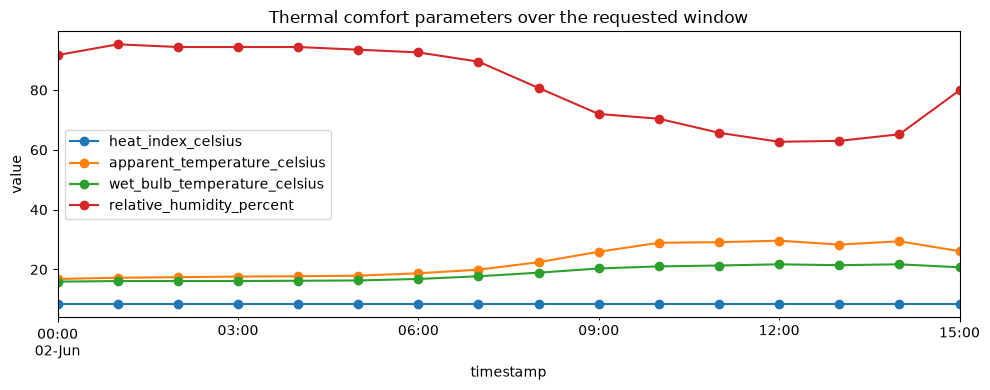

In [4]:
import matplotlib.pyplot as plt

to_plot = [c for c in ['heat_index_celsius', 'apparent_temperature_celsius', 'wet_bulb_temperature_celsius', 'relative_humidity_percent'] if c in df.columns]
if to_plot:
    df[to_plot].plot(figsize=(10, 4), marker='o')
    plt.title('Thermal comfort parameters over the requested window')
    plt.ylabel('value'); plt.tight_layout(); plt.show()

In [5]:
solar = location.get('solar_irradiance', {}).get('clear_sky', {})
print('Clear-sky solar irradiance (W/m²):')
for comp in ('ghi', 'dni', 'dhi'):
    print(f'  {comp.upper():>5}: {solar.get(comp)}')

Clear-sky solar irradiance (W/m²):
    GHI: 436.66
    DNI: 481.92
    DHI: 71.87
